<a href="https://colab.research.google.com/github/minhaz-engg/Time-Series-try/blob/main/neuralforecast__XLinear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
!pip install neuralforecast

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                 ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                 │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train         │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler               │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ projection           │ Sequential    │  6.8 K │ train │     0 │
│ 4 │ temporal_gating      │ GatingBlock   │  131 K │ train │     0 │
│ 5 │ channel_gating       │ GatingBlock   │    280 │ train │     0 │
│ 6 │ hist_exog_projection │ Linear        │  6.8 K │ train │     0 │
│ 7 │ futr_exog_projection │ Linear        │ 32.9 K │ train │     0 │
│ 8 │ stat_exog_projection │ Linear        │    384 │ train │     0 │
│ 9 │ head                 │ Sequential    │  7.7 K │ train │     0 │
│   │ other params         │ n/a           │  1.0 K │ n/a   │   n/a │
└───┴──────────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 187 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 187 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 26                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


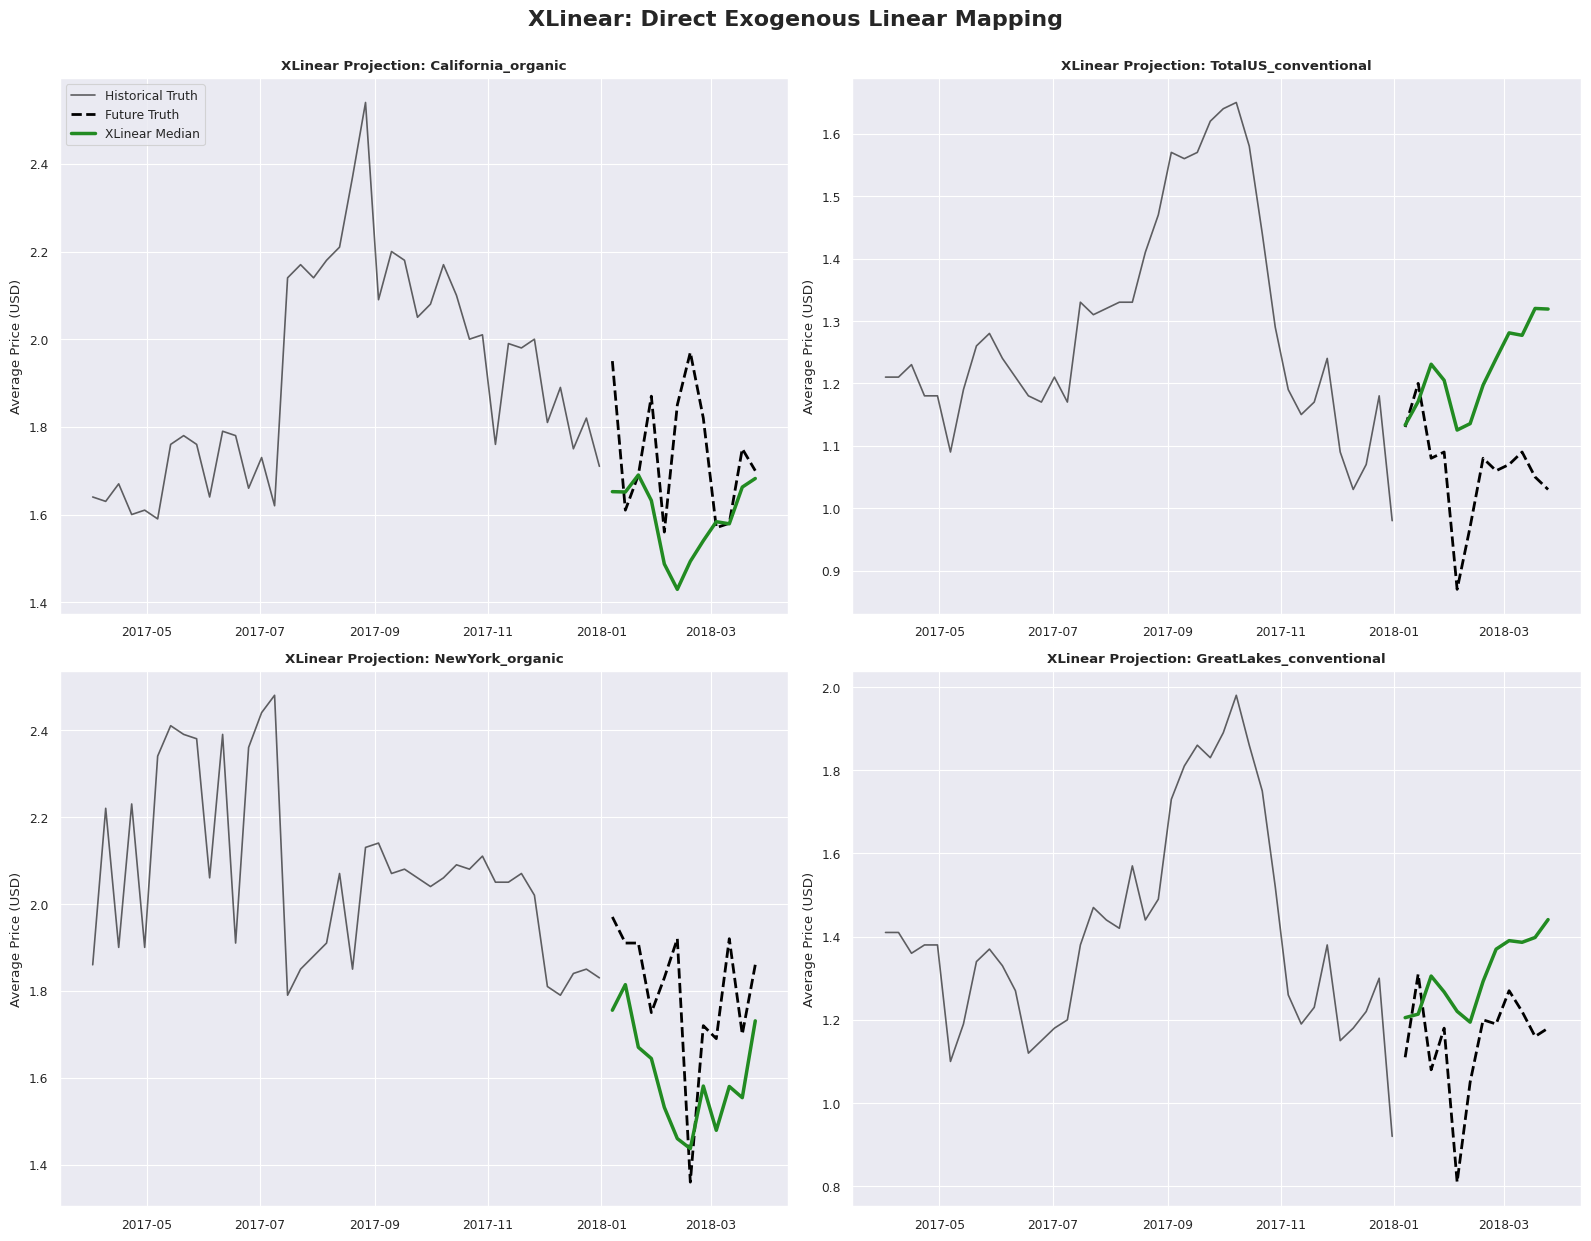

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from neuralforecast import NeuralForecast
from neuralforecast.models import XLinear
from neuralforecast.losses.pytorch import MAE

# ==========================================
# 1. Ingestion & Topological Restructuring
# ==========================================
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/avocado.csv"
df = pd.read_csv(url, index_col=0)

df['ds'] = pd.to_datetime(df['Date'])
df['y'] = df['AveragePrice']
df['unique_id'] = df['region'] + "_" + df['type']

target_regions = ['California', 'NewYork', 'TotalUS', 'GreatLakes']
df = df[df['region'].isin(target_regions)].copy()

# ==========================================
# 2. Exogenous Engineering (Manual Bypass)
# ==========================================
# Historical Volume Dynamics
df['log_volume'] = np.log1p(df['Total Volume']).astype('float32')

# Deterministic Calendar Vectors
df['week_of_year'] = df['ds'].dt.isocalendar().week.astype('float32')
df['month_of_year'] = df['ds'].dt.month.astype('float32')
df['week_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52.0).astype('float32')
df['week_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52.0).astype('float32')

calendar_cols = ['week_of_year', 'month_of_year', 'week_sin', 'week_cos']
dynamic_cols = ['unique_id', 'ds', 'y', 'log_volume'] + calendar_cols
df = df[dynamic_cols].sort_values(['unique_id', 'ds']).reset_index(drop=True)

# ==========================================
# 3. Forge the Immutable Static Substrate
# ==========================================
static_df = df[['unique_id']].drop_duplicates().reset_index(drop=True)

static_df['is_organic'] = static_df['unique_id'].apply(
    lambda x: 1.0 if x.split('_')[1] == 'organic' else 0.0
).astype(np.float32)

region_map = {reg: i for i, reg in enumerate(target_regions)}
static_df['region_enc'] = static_df['unique_id'].apply(
    lambda x: region_map[x.split('_')[0]]
).astype(np.float32)

# ==========================================
# 4. Temporal Bifurcation (Train/Test)
# ==========================================
horizon = 12
global_max_date = df['ds'].max()
cutoff_date = global_max_date - pd.Timedelta(weeks=horizon)

Y_train_df = df[df['ds'] <= cutoff_date].reset_index(drop=True)
Y_test_df = df[df['ds'] > cutoff_date].reset_index(drop=True)

# ==========================================
# 5. XLinear Initialization
# ==========================================
n_concurrent_series = len(Y_train_df['unique_id'].unique())

model = XLinear(
    h=horizon,
    input_size=52,              # 52-week receptive field
    n_series=n_concurrent_series,

    # Exogenous Integration:
    stat_exog_list=['is_organic', 'region_enc'],
    hist_exog_list=['log_volume'],
    futr_exog_list=calendar_cols,

    # XLinear relies on pure linear mappings, making MAE an excellent objective
    loss=MAE(),
    scaler_type='robust',
    learning_rate=1e-3,
    max_steps=300,
    val_check_steps=10,
    early_stop_patience_steps=3,
    batch_size=32
)

fcst = NeuralForecast(models=[model], freq='W')
fcst.fit(df=Y_train_df, static_df=static_df, val_size=horizon)
forecasts = fcst.predict(futr_df=Y_test_df)

# ==========================================
# 6. Advanced Empirical Visualization
# ==========================================
Y_hat_df = forecasts.reset_index(drop=False)
merged_plot_df = pd.merge(Y_test_df, Y_hat_df, on=['unique_id', 'ds'], how='inner')

sns.set_theme(style="darkgrid", context="paper")
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=False)
axes = axes.flatten()

sample_uids = ['California_organic', 'TotalUS_conventional', 'NewYork_organic', 'GreatLakes_conventional']

for idx, uid in enumerate(sample_uids):
    ax = axes[idx]

    train_subset = Y_train_df[Y_train_df['unique_id'] == uid].tail(40)
    test_subset = merged_plot_df[merged_plot_df['unique_id'] == uid]

    ax.plot(train_subset['ds'], train_subset['y'], color='black', alpha=0.6, label='Historical Truth')
    ax.plot(test_subset['ds'], test_subset['y'], color='black', linestyle='--', linewidth=2, label='Future Truth')

    # XLinear produces deterministic (point) forecasts by default, hence a single solid line
    ax.plot(test_subset['ds'], test_subset['XLinear'], color='forestgreen', linewidth=2.5, label='XLinear Median')

    ax.set_title(f"XLinear Projection: {uid}", fontweight='bold')
    ax.set_ylabel("Average Price (USD)")

    if idx == 0:
        ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.suptitle("XLinear: Direct Exogenous Linear Mapping", y=1.03, fontsize=16, fontweight='bold')
plt.show()